<a href="https://colab.research.google.com/github/SrilathaWeb/Data-Science-Cohort-20/blob/main/Project-4/Spotify_Project_4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Project 4: Music Popularity Prediction


This project will take data features collected for songs that have been on the Top 200 Weekly (Global) charts of Spotify in 2020 & 2021. The popularity of the song will be predicted using a tree-based regression model trained on these features.



The goals for the project are:

- Minimize the cross-validated ***root mean squared error ( RMSE )*** when predicting the popularity of a new song.

- Determine the importance of the features in driving the regression result.
The project will be done using tree-based regression techniques as covered in class. The hyperparameters of the trees should be carefully selected to avoid over-fitting.


There are three main challenges for this project:

1. Determining the outcome ( i.e. target ).  There is a "popularity" column.  But other columns may or may not be more appropriate indicators of popularity.

1. Choosing appropriate predictors ( i.e. features ). When building a machine learning model, we want to make sure that we consider how the model will be ultimately used. For this project, we are predicting the popularity of a new song. Therefore, we should only include the predictors we would have for a new song. It might help to imagine that the song will not be released for several weeks.

1. Data cleaning and feature engineering. Some creative cleaning and/or feature engineering may be needed to extract useful information for prediction.



Once again, be sure to go through the whole data science process and document as such in your Jupyter notebook.

The data is available AWS at https://ddc-datascience.s3.amazonaws.com/Projects/Project.4-Spotify/Data/Spotify.csv .



In [ ]:
url = "https://ddc-datascience.s3.amazonaws.com/Projects/Project.4-Spotify/Data/Spotify.csv"
!curl -s -I {url}

HTTP/1.1 200 OK
x-amz-id-2: 6Ypvsxbqk7eR9tlOrVdhYYn4opiUMPlQomqC/5Y3XYYIzbrsmhpM59/iJnrGYVd0+wLCKch21Hs=
x-amz-request-id: PPEY2YW1ZVCF3SSR
Date: Tue, 19 May 2026 22:13:24 GMT
Last-Modified: Wed, 04 Oct 2023 17:23:56 GMT
ETag: "65b9875b11e0d7ea03ee2af024f45e99"
x-amz-server-side-encryption: AES256
Accept-Ranges: bytes
Content-Type: text/csv
Content-Length: 738124
Server: AmazonS3



In [ ]:
!curl -s -O {url}

In [ ]:
ls -la

total 740
drwxr-xr-x 1 root root   4096 May 19 20:33 ./
drwxr-xr-x 1 root root   4096 May 19 20:28 ../
drwxr-xr-x 4 root root   4096 May 12 13:29 .config/
drwxr-xr-x 1 root root   4096 May 12 13:29 sample_data/
-rw-r--r-- 1 root root 738124 May 19 22:13 Spotify.csv


In [ ]:
!head -1 Spotify.csv | tr , '\n' | cat -n

     1	Index
     2	Highest Charting Position
     3	Number of Times Charted
     4	Week of Highest Charting
     5	Song Name
     6	Streams
     7	Artist
     8	Artist Followers
     9	Song ID
    10	Genre
    11	Release Date
    12	Weeks Charted
    13	Popularity
    14	Danceability
    15	Energy
    16	Loudness
    17	Speechiness
    18	Acousticness
    19	Liveness
    20	Tempo
    21	Duration (ms)
    22	Valence
    23	Chord


# Problem Defination

In this project, I am predicting Spotify song popularity using song and audio features. Since the target variable is numeric, this is a regression problem. The goal is to minimize cross-validated RMSE and identify the most important features affecting popularity.

The main target can be: Popularity

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn import datasets
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_squared_error
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error



In [ ]:
url = "https://ddc-datascience.s3.amazonaws.com/Projects/Project.4-Spotify/Data/Spotify.csv"
df_spotify = pd.read_csv(url)
df_spotify.head(2)

,Index,Highest Charting Position,Number of Times Charted,Week of Highest Charting,Song Name,Streams,Artist,Artist Followers,Song ID,Genre,...,Danceability,Energy,Loudness,Speechiness,Acousticness,Liveness,Tempo,Duration (ms),Valence,Chord
0,1,1,8,2021-07-23--2021-07-30,Beggin',"48,633,449",Måneskin,3377762,3Wrjm47oTz2sjIgck11l5e,"['indie rock italiano', 'italian pop']",...,0.714,0.8,-4.808,0.0504,0.127,0.359,134.002,211560,0.589,B
1,2,2,3,2021-07-23--2021-07-30,STAY (with Justin Bieber),"47,248,719",The Kid LAROI,2230022,5HCyWlXZPP0y6Gqq8TgA20,['australian hip hop'],...,0.591,0.764,-5.484,0.0483,0.0383,0.103,169.928,141806,0.478,C#/Db


In [ ]:
df_spotify.shape
df_spotify.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1556 entries, 0 to 1555
Data columns (total 23 columns):
 #   Column                     Non-Null Count  Dtype 
---  ------                     --------------  ----- 
 0   Index                      1556 non-null   int64 
 1   Highest Charting Position  1556 non-null   int64 
 2   Number of Times Charted    1556 non-null   int64 
 3   Week of Highest Charting   1556 non-null   object
 4   Song Name                  1556 non-null   object
 5   Streams                    1556 non-null   object
 6   Artist                     1556 non-null   object
 7   Artist Followers           1556 non-null   object
 8   Song ID                    1556 non-null   object
 9   Genre                      1556 non-null   object
 10  Release Date               1556 non-null   object
 11  Weeks Charted              1556 non-null   object
 12  Popularity                 1556 non-null   object
 13  Danceability               1556 non-null   object
 14  Energy  

In [ ]:
df_spotify.describe().transpose()

,count,mean,std,min,25%,50%,75%,max
Index,1556.0,778.500000,449.322824,1.0,389.75,778.5,1167.25,1556.0
Highest Charting Position,1556.0,87.744216,58.147225,1.0,37.00,80.0,137.00,200.0
Number of Times Charted,1556.0,10.668380,16.360546,1.0,1.00,4.0,12.00,142.0


In [ ]:
df_spotify.columns = df_spotify.columns.str.strip()
df_spotify.columns

Index(['Index', 'Highest Charting Position', 'Number of Times Charted',
       'Week of Highest Charting', 'Song Name', 'Streams', 'Artist',
       'Artist Followers', 'Song ID', 'Genre', 'Release Date', 'Weeks Charted',
       'Popularity', 'Danceability', 'Energy', 'Loudness', 'Speechiness',
       'Acousticness', 'Liveness', 'Tempo', 'Duration (ms)', 'Valence',
       'Chord'],
      dtype='object')

In [ ]:
df_spotify.isnull().sum()

,0
Index,0
Highest Charting Position,0
Number of Times Charted,0
Week of Highest Charting,0
Song Name,0
Streams,0
Artist,0
Artist Followers,0
Song ID,0
Genre,0


In [ ]:
df_spotify.dtypes

,0
Index,int64
Highest Charting Position,int64
Number of Times Charted,int64
Week of Highest Charting,object
Song Name,object
Streams,object
Artist,object
Artist Followers,object
Song ID,object
Genre,object


# Data Cleaning


In [ ]:
#df_spotify["Popularity"] = pd.to_numeric(df_spotify["Popularity"], errors="coerce")
#df_spotify["Popularity"].dtype

In [ ]:
df_spotify = df_spotify.drop("Index", axis=1)
df_spotify.head(2)

,Highest Charting Position,Number of Times Charted,Week of Highest Charting,Song Name,Streams,Artist,Artist Followers,Song ID,Genre,Release Date,...,Danceability,Energy,Loudness,Speechiness,Acousticness,Liveness,Tempo,Duration (ms),Valence,Chord
0,1,8,2021-07-23--2021-07-30,Beggin',"48,633,449",Måneskin,3377762,3Wrjm47oTz2sjIgck11l5e,"['indie rock italiano', 'italian pop']",2017-12-08,...,0.714,0.8,-4.808,0.0504,0.127,0.359,134.002,211560,0.589,B
1,2,3,2021-07-23--2021-07-30,STAY (with Justin Bieber),"47,248,719",The Kid LAROI,2230022,5HCyWlXZPP0y6Gqq8TgA20,['australian hip hop'],2021-07-09,...,0.591,0.764,-5.484,0.0483,0.0383,0.103,169.928,141806,0.478,C#/Db


In [ ]:
numeric_cols = df_spotify.select_dtypes(include=["int64", "float64"]).columns
object_cols = df_spotify.select_dtypes(include=["object"]).columns
numeric_cols , object_cols

(Index(['Highest Charting Position', 'Number of Times Charted'], dtype='object'),
 Index(['Week of Highest Charting', 'Song Name', 'Streams', 'Artist',
        'Artist Followers', 'Song ID', 'Genre', 'Release Date', 'Weeks Charted',
        'Popularity', 'Danceability', 'Energy', 'Loudness', 'Speechiness',
        'Acousticness', 'Liveness', 'Tempo', 'Duration (ms)', 'Valence',
        'Chord'],
       dtype='object'))

In [ ]:
df_spotify_copy = df_spotify.copy()

In [ ]:
def is_numeric_text_column(series, threshold=0.1):
    s = series.dropna().astype(str).str.strip()
    s = s.str.replace(",", "", regex=False)
    #print(s)
    numeric_pattern = r"^-?\d+(\.\d+)?$"

    match_rate = s.str.match(numeric_pattern).mean()

    return match_rate >= threshold

In [ ]:
# Check object columns
object_cols = df_spotify.select_dtypes(include="object").columns

numeric_object_cols = []

for col in object_cols:
    if is_numeric_text_column(df_spotify[col]):
      numeric_object_cols.append(col)
      df_spotify[col] = df_spotify[col].astype(str).str.strip()
      df_spotify[col] = df_spotify[col].str.replace(",", "", regex=False)
      df_spotify[col] = pd.to_numeric(df_spotify[col],errors="coerce")
      print(df_spotify[col].dtypes)
     # df_spotify[col] = pd.to_numeric(df_spotify[col], errors="coerce")

print(numeric_object_cols)

int64
float64
float64
float64
float64
float64
float64
float64
float64
float64
float64
float64
['Streams', 'Artist Followers', 'Popularity', 'Danceability', 'Energy', 'Loudness', 'Speechiness', 'Acousticness', 'Liveness', 'Tempo', 'Duration (ms)', 'Valence']


In [ ]:
df_spotify[numeric_object_cols].info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1556 entries, 0 to 1555
Data columns (total 12 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Streams           1556 non-null   int64  
 1   Artist Followers  1545 non-null   float64
 2   Popularity        1545 non-null   float64
 3   Danceability      1545 non-null   float64
 4   Energy            1545 non-null   float64
 5   Loudness          1545 non-null   float64
 6   Speechiness       1545 non-null   float64
 7   Acousticness      1545 non-null   float64
 8   Liveness          1545 non-null   float64
 9   Tempo             1545 non-null   float64
 10  Duration (ms)     1545 non-null   float64
 11  Valence           1545 non-null   float64
dtypes: float64(11), int64(1)
memory usage: 146.0 KB


In [ ]:
df_spotify_num = df_spotify[numeric_object_cols]
df_spotify_num

,Streams,Artist Followers,Popularity,Danceability,Energy,Loudness,Speechiness,Acousticness,Liveness,Tempo,Duration (ms),Valence
0,48633449,3377762.0,100.0,0.714,0.800,-4.808,0.0504,0.12700,0.3590,134.002,211560.0,0.589
1,47248719,2230022.0,99.0,0.591,0.764,-5.484,0.0483,0.03830,0.1030,169.928,141806.0,0.478
2,40162559,6266514.0,99.0,0.563,0.664,-5.044,0.1540,0.33500,0.0849,166.928,178147.0,0.688
3,37799456,83293380.0,98.0,0.808,0.897,-3.712,0.0348,0.04690,0.3640,126.026,231041.0,0.591
4,33948454,5473565.0,96.0,0.736,0.704,-7.409,0.0615,0.02030,0.0501,149.995,212000.0,0.894
...,...,...,...,...,...,...,...,...,...,...,...,...
1551,4630675,27167675.0,79.0,0.762,0.700,-6.021,0.0694,0.00261,0.1530,116.073,209320.0,0.608
1552,4623030,15019109.0,66.0,0.528,0.870,-3.123,0.0851,0.24000,0.3330,152.370,181930.0,0.714
1553,4620876,22698747.0,81.0,0.765,0.523,-4.333,0.0300,0.18400,0.1320,104.988,217307.0,0.394
1554,4607385,208630.0,60.0,0.832,0.550,-7.026,0.0587,0.24900,0.1820,154.064,152784.0,0.881


In [ ]:
df_spotify_num[df_spotify_num.isna().any(axis=1)]

,Streams,Artist Followers,Popularity,Danceability,Energy,Loudness,Speechiness,Acousticness,Liveness,Tempo,Duration (ms),Valence
35,11869336,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
163,5453159,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
464,6292362,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
530,6162453,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
636,8804531,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
654,10509961,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
750,5358940,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
784,4739241,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
876,4964708,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1140,5494500,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
row_index = 35

compare = pd.DataFrame({
    "Before": df_spotify_copy.loc[row_index, numeric_object_cols],
    "After": df_spotify_num.loc[row_index, numeric_object_cols]
})
compare

,Before,After
Streams,"11,869,336",11869336.0
Artist Followers,,NaN
Popularity,,NaN
Danceability,,NaN
Energy,,NaN
Loudness,,NaN
Speechiness,,NaN
Acousticness,,NaN
Liveness,,NaN
Tempo,,NaN


In [ ]:
df_spotify_num = df_spotify_num.dropna(subset=numeric_object_cols)

In [ ]:
df_spotify_num.isna().sum()[df_spotify_num.isna().sum() > 0]

,0


In [ ]:
df_spotify_num

,Streams,Artist Followers,Popularity,Danceability,Energy,Loudness,Speechiness,Acousticness,Liveness,Tempo,Duration (ms),Valence
0,48633449,3377762.0,100.0,0.714,0.800,-4.808,0.0504,0.12700,0.3590,134.002,211560.0,0.589
1,47248719,2230022.0,99.0,0.591,0.764,-5.484,0.0483,0.03830,0.1030,169.928,141806.0,0.478
2,40162559,6266514.0,99.0,0.563,0.664,-5.044,0.1540,0.33500,0.0849,166.928,178147.0,0.688
3,37799456,83293380.0,98.0,0.808,0.897,-3.712,0.0348,0.04690,0.3640,126.026,231041.0,0.591
4,33948454,5473565.0,96.0,0.736,0.704,-7.409,0.0615,0.02030,0.0501,149.995,212000.0,0.894
...,...,...,...,...,...,...,...,...,...,...,...,...
1551,4630675,27167675.0,79.0,0.762,0.700,-6.021,0.0694,0.00261,0.1530,116.073,209320.0,0.608
1552,4623030,15019109.0,66.0,0.528,0.870,-3.123,0.0851,0.24000,0.3330,152.370,181930.0,0.714
1553,4620876,22698747.0,81.0,0.765,0.523,-4.333,0.0300,0.18400,0.1320,104.988,217307.0,0.394
1554,4607385,208630.0,60.0,0.832,0.550,-7.026,0.0587,0.24900,0.1820,154.064,152784.0,0.881


In [ ]:
from sklearn.preprocessing import LabelEncoder

def clean_and_convert_numeric_text(df, threshold=0.8):
    df_cleaned = df.copy()

    # Clean column names
    df_cleaned.columns = df_cleaned.columns.str.strip()

    numeric_object_cols = []
    categorical_cols = []

    object_cols = df_cleaned.select_dtypes(include="object").columns
    numeric_pattern = r"^-?\d+(\.\d+)?$"

    for col in object_cols:
        s = df_cleaned[col].astype(str).str.strip()
        s_clean = s.str.replace(",", "", regex=False)

        not_missing = df_cleaned[col].notna()
        match_rate = s_clean[not_missing].str.match(numeric_pattern).mean()

        if match_rate >= threshold:
            numeric_object_cols.append(col)
            df_cleaned[col] = pd.to_numeric(s_clean, errors="coerce")
        else:
            categorical_cols.append(col)

    # Drop rows where numeric conversion created NaN
    if numeric_object_cols:
        df_cleaned = df_cleaned.dropna(subset=numeric_object_cols)

    # Keep only Genre and Chord as categorical columns
    categorical_to_keep = ["Genre", "Chord"]

    categorical_to_drop = [
        col for col in categorical_cols
        if col not in categorical_to_keep
    ]

    df_cleaned = df_cleaned.drop(columns=categorical_to_drop, errors="ignore")

    # Label encode Genre and Chord
    label_encoders = {}

    for col in categorical_to_keep:
        if col in df_cleaned.columns:
            encoder = LabelEncoder()
            df_cleaned[col] = df_cleaned[col].astype(str).str.strip()
            df_cleaned[col] = encoder.fit_transform(df_cleaned[col])
            label_encoders[col] = encoder
    leakage_cols = [
        "Highest Charting Position",
        "Number of Times Charted",
        "Streams"
    ]

    df_cleaned = df_cleaned.drop(columns=leakage_cols, errors="ignore")
    print("Converted numeric columns:")
    print(numeric_object_cols)

    print("\nDropped categorical columns:")
    print(categorical_to_drop)

    print("\nFinal dataframe shape:")
    print(df_cleaned.shape)

    print("\nRemaining object columns:")
    print(df_cleaned.select_dtypes(include="object").columns)

    return df_cleaned, numeric_object_cols, categorical_to_drop, label_encoders

In [ ]:
df_spotify_new, converted_cols, dropped_cols, label_encoders = clean_and_convert_numeric_text(
    df_spotify_copy,
    threshold=0.8
)

df_spotify_new.head(2)

Converted numeric columns:
['Streams', 'Artist Followers', 'Popularity', 'Danceability', 'Energy', 'Loudness', 'Speechiness', 'Acousticness', 'Liveness', 'Tempo', 'Duration (ms)', 'Valence']

Dropped categorical columns:
['Week of Highest Charting', 'Song Name', 'Artist', 'Song ID', 'Release Date', 'Weeks Charted']

Final dataframe shape:
(1545, 13)

Remaining object columns:
Index([], dtype='object')


,Artist Followers,Genre,Popularity,Danceability,Energy,Loudness,Speechiness,Acousticness,Liveness,Tempo,Duration (ms),Valence,Chord
0,3377762.0,276,100.0,0.714,0.800,-4.808,0.0504,0.1270,0.359,134.002,211560.0,0.589,2
1,2230022.0,63,99.0,0.591,0.764,-5.484,0.0483,0.0383,0.103,169.928,141806.0,0.478,4


In [ ]:
df_spotify_new.select_dtypes(include="object").columns

Index([], dtype='object')

# Decision Tree Regression

In [ ]:
X = df_spotify_new.drop("Popularity", axis=1)
y = df_spotify_new["Popularity"]

In [ ]:
numLoops = 500
rms_error = np.zeros(numLoops)

for index in range(0,numLoops):
  X_train , X_test, y_train, y_test = train_test_split(X, y, test_size =0.2)
  model = DecisionTreeRegressor(max_depth = 5)
  model.fit(X_train, y_train)
  y_predict = model.predict(X_test)
  rms_error[index] = np.sqrt(mean_squared_error(y_test, y_predict))

print(f"CV RMSE : {rms_error.mean().round(2)}")

CV RMSE : 10.93


#How do we choose the tree depth?
Based on rms and std error less

In [ ]:
max_depths = [1,2,3,4,5,6,7,8,9,10]
rms_depth = np.zeros(len(max_depths))
std_depth = np.zeros(len(max_depths))

numLoops = 500

for n, depth in enumerate(max_depths):
  rms_error = np.zeros(numLoops)

  for idx in range(0,numLoops):
    X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2)
    model = DecisionTreeRegressor(max_depth=depth)
    model.fit(X_train,y_train)
    y_pred = model.predict(X_test)
    rms_error[idx] = np.sqrt(mean_squared_error(y_test, y_pred))

  rms_depth[n] = rms_error.mean()
  std_depth[n] = rms_error.std( ddof = 1 )


In [ ]:
pd.DataFrame( zip( max_depths, rms_depth, std_depth ) )


,0,1,2
0,1,13.145226,0.751598
1,2,10.526568,0.670154
2,3,10.641027,0.788685
3,4,10.749052,0.757922
4,5,10.866228,0.832597
5,6,10.992693,0.858067
6,7,11.201498,0.876192
7,8,11.289149,0.901758
8,9,11.565264,0.879863
9,10,11.701573,0.887335


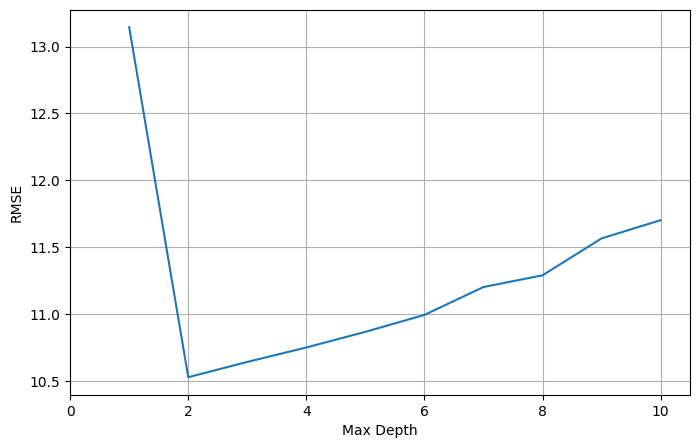

In [ ]:
# Plot result
plt.figure(figsize = (8,5))
plt.plot(max_depths, rms_depth)
plt.xlabel('Max Depth')
plt.ylabel('RMSE')
plt.xlim(0, 10.5)
plt.grid()


In [ ]:
numLoops = 500
rms_error = np.zeros(numLoops)

for index in range(0,numLoops):
  X_train , X_test, y_train, y_test = train_test_split(X, y, test_size =0.2)
  model_dt = DecisionTreeRegressor(max_depth = 3)
  model_dt.fit(X_train, y_train)
  y_predict = model_dt.predict(X_test)
  rms_error[index] = np.sqrt(mean_squared_error(y_test, y_predict))

print(f"CV RMSE : {rms_error.mean().round(2)}")

CV RMSE : 10.68


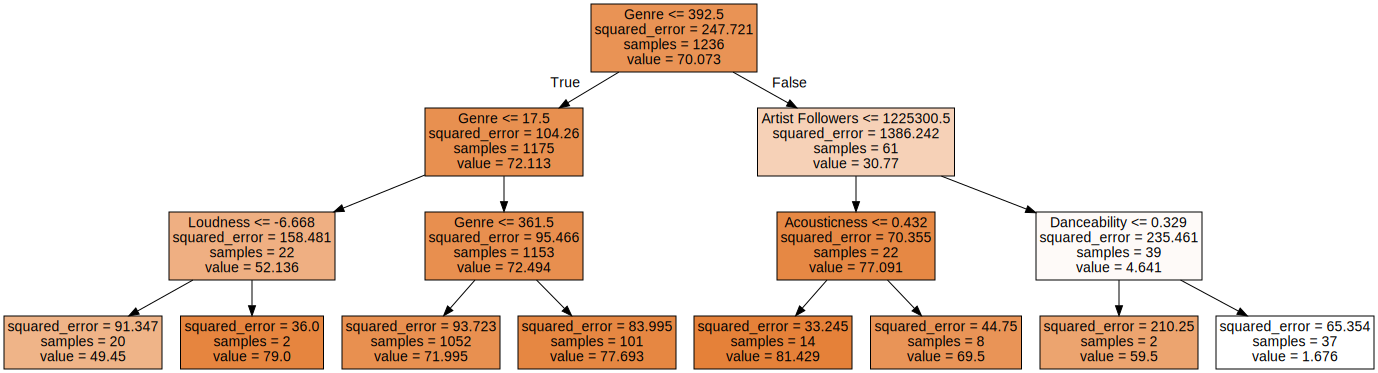

In [ ]:
import graphviz
from IPython.display import display
from sklearn import tree

display (
    graphviz.Source(
        tree.export_graphviz(
            model_dt,
            feature_names=X.columns,
            filled = True,
        )
    )
)


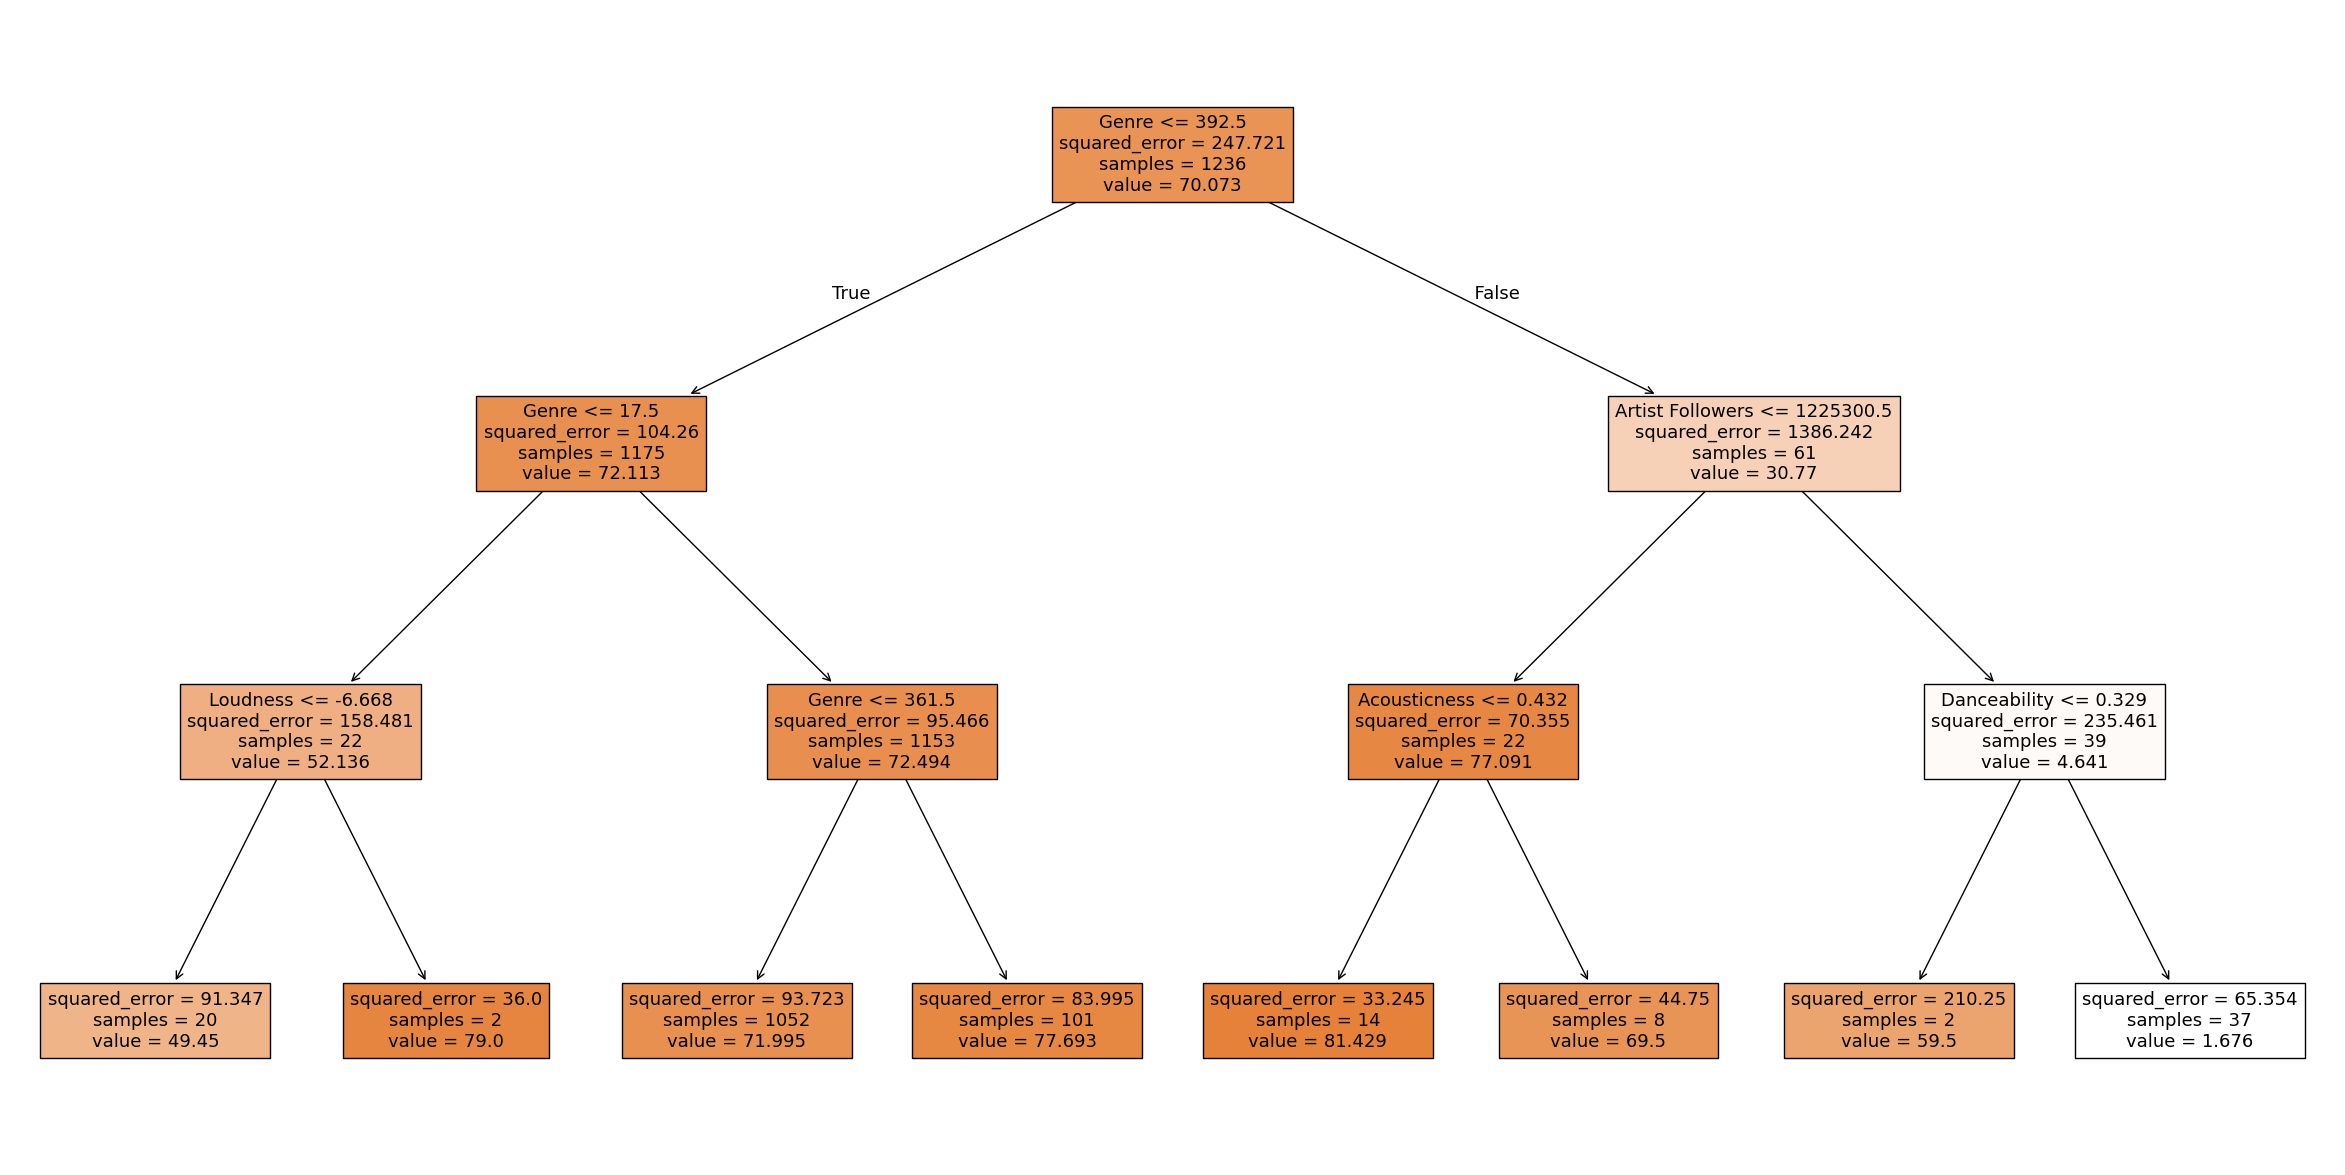

In [ ]:
# Option 2
plt.figure(figsize=(30,15))
tree_plot = tree.plot_tree(
  model_dt,
  feature_names = X.columns,
  filled=True,
)


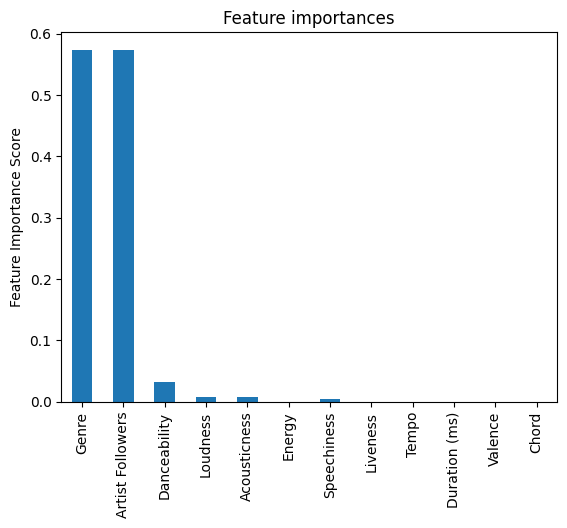

In [ ]:
importances = model_dt.feature_importances_
tree_importances = pd.Series( importances, index = X.columns )

plt.figure()
tree_importances.plot.bar()
tree_importances.sort_values( ascending = False ).plot.bar()
plt.title("Feature importances")
plt.ylabel('Feature Importance Score') ;


In [ ]:
( tree_importances.sort_values( ascending = False ) * 100 ).cumsum()


,0
Genre,57.380624
Artist Followers,95.527381
Danceability,98.805411
Loudness,99.625720
Acousticness,100.000000
Energy,100.000000
Speechiness,100.000000
Liveness,100.000000
Tempo,100.000000
Duration (ms),100.000000


# Random Forest


In [ ]:
from sklearn.ensemble import RandomForestRegressor
# two parameters - n_estimators (number of trees), max_depth (number of splits)
numLoops = 500

mean_error = np.zeros(numLoops)

# np.random.seed(42)
for idx in range(0,numLoops):
  X_train, X_test, y_train, y_test = train_test_split( X, y, test_size = 0.2 )
  model_rf = RandomForestRegressor( n_estimators = 10 ) #n_estimators is number of trees in forest. Note: you can also choose max_depth for RFs
  model_rf.fit( X_train, y_train )
  y_pred_rf = model_rf.predict( X_test )
  mean_error[idx] = mean_squared_error( y_test, y_pred_rf )

rmse_rf = np.sqrt(mean_error)
print(f'RMSE: {rmse_rf.mean()}')
print(f'RMSE_std: {rmse_rf.std()}')
rmse_rf[:50]


RMSE: 10.495378027503145
RMSE_std: 0.7254804543539117


array([10.04016207,  9.5913172 , 10.17703169, 10.54408529, 11.7766485 ,
       10.43629775, 10.75861085,  9.91246967, 11.07031659, 10.12754902,
       10.39584339,  9.94546221, 10.37792342, 10.41060264,  9.69238553,
        9.31374389, 10.47850474,  9.93793378, 10.11279749, 10.82206035,
       10.87929062, 11.7673524 , 11.13095353, 10.34085435, 10.22675437,
        9.68536914, 10.78990465, 10.05329488, 12.29795679,  9.93758027,
       11.47293628, 10.83171061, 10.78400169,  9.57555038,  9.57350544,
       10.21694766,  9.69437905,  9.78779704, 10.64208991, 10.0087001 ,
       10.98398543, 11.39099031, 10.2244282 ,  9.66195455, 11.44079172,
       10.67734649, 10.49531873, 10.41302589, 10.10099646, 10.8252103 ])

# XGBoost


In [ ]:
import xgboost as xgb

numLoops = 500
mse_xgb  = np.zeros(numLoops)

for idx in range(0,numLoops):
  X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2)
  xgbr = xgb.XGBRegressor(objective ='reg:squarederror', verbosity=0, seed = 10)
  xgbr.fit(X_train,y_train)
  y_pred_xgb = xgbr.predict(X_test)
  mse_xgb[idx] = mean_squared_error(y_test,y_pred_xgb)

print(f'RMSE: {np.sqrt(mse_xgb).mean()}')


RMSE: 10.390179705462767


# Comparing Decision Tree, Random Forest, XGBoost

In [ ]:

# Predictions
y_pred_dt = model_dt.predict(X_test)
y_pred_rf = model_rf.predict(X_test)
y_pred_gb = xgbr.predict(X_test)

# RMSE values
rmse_dt = np.sqrt(mean_squared_error(y_test, y_pred_dt))
rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))
rmse_gb = np.sqrt(mean_squared_error(y_test, y_pred_xgb))

# Compare in table
model_results = pd.DataFrame({
    "Model": ["Decision Tree", "Random Forest", "XGBoosting"],
    "RMSE": [rmse_dt, rmse_rf, rmse_gb]
})

model_results = model_results.sort_values(by="RMSE")
model_results

,Model,RMSE
1,Random Forest,6.518322
0,Decision Tree,10.175977
2,XGBoosting,11.019271


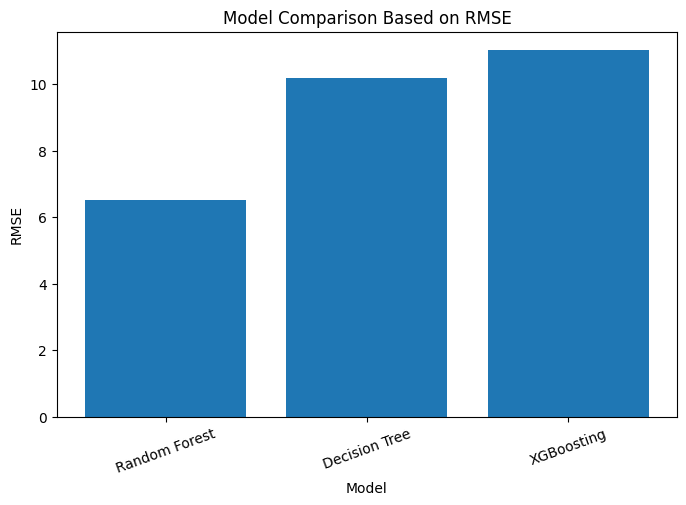

In [ ]:
plt.figure(figsize=(8,5))
plt.bar(model_results["Model"], model_results["RMSE"])
plt.xlabel("Model")
plt.ylabel("RMSE")
plt.title("Model Comparison Based on RMSE")
plt.xticks(rotation=20)
plt.show()

In [ ]:
df_model = df_spotify_copy.copy()

In [ ]:
# df_spotify, converted_cols = clean_and_convert_numeric_text(df_spotify, threshold=0.1)
# print("Converted columns:", converted_cols)

In [ ]:
# def is_numeric_text_column(series, threshold=0.1):
#     s = series.dropna().astype(str).str.strip()
#     s = s.str.replace(",", "", regex=False)
#     #print(s)
#     numeric_pattern = r"^-?\d+(\.\d+)?$"

#     match_rate = s.str.match(numeric_pattern).mean()

#     return match_rate >= threshold

# # Check object columns
# object_cols = df_model.select_dtypes(include="object").columns

# numeric_object_cols = []

# for col in object_cols:
#     if is_numeric_text_column(df_model[col]):
#       numeric_object_cols.append(col)
#       df_model[col] = df_model[col].astype(str).str.strip()
#       df_model[col] = df_model[col].str.replace(",", "", regex=False)
#       df_model[col] = pd.to_numeric(df_model[col],errors="coerce")
#       print(df_model[col].dtypes)
#      # df_spotify[col] = pd.to_numeric(df_spotify[col], errors="coerce")

# print(numeric_object_cols)
# df_model = df_model.dropna(subset=numeric_object_cols)
# df_model.isna().sum()[df_model.isna().sum() > 0]
# df_model.dtypes

In [ ]:
df_model, converted_cols, dropped_cols, label_encoders = clean_and_convert_numeric_text(
    df_spotify_copy,
    threshold=0.8
)

df_model.head()

Converted numeric columns:
['Streams', 'Artist Followers', 'Popularity', 'Danceability', 'Energy', 'Loudness', 'Speechiness', 'Acousticness', 'Liveness', 'Tempo', 'Duration (ms)', 'Valence']

Dropped categorical columns:
['Week of Highest Charting', 'Song Name', 'Artist', 'Song ID', 'Release Date', 'Weeks Charted']

Final dataframe shape:
(1545, 13)

Remaining object columns:
Index([], dtype='object')


,Artist Followers,Genre,Popularity,Danceability,Energy,Loudness,Speechiness,Acousticness,Liveness,Tempo,Duration (ms),Valence,Chord
0,3377762.0,276,100.0,0.714,0.800,-4.808,0.0504,0.1270,0.3590,134.002,211560.0,0.589,2
1,2230022.0,63,99.0,0.591,0.764,-5.484,0.0483,0.0383,0.1030,169.928,141806.0,0.478,4
2,6266514.0,364,99.0,0.563,0.664,-5.044,0.1540,0.3350,0.0849,166.928,178147.0,0.688,0
3,83293380.0,363,98.0,0.808,0.897,-3.712,0.0348,0.0469,0.3640,126.026,231041.0,0.591,2
4,5473565.0,312,96.0,0.736,0.704,-7.409,0.0615,0.0203,0.0501,149.995,212000.0,0.894,6


In [ ]:
df_song_info = df_spotify_copy[["Song Name", "Artist"]].dropna()

In [ ]:
song_names = df_spotify_copy.loc[df_spotify_new.index, "Song Name"]
artists = df_spotify_copy.loc[df_spotify_new.index, "Artist"]
song_names

,Song Name
0,Beggin'
1,STAY (with Justin Bieber)
2,good 4 u
3,Bad Habits
4,INDUSTRY BABY (feat. Jack Harlow)
...,...
1551,New Rules
1552,Cheirosa - Ao Vivo
1553,Havana (feat. Young Thug)
1554,Surtada - Remix Brega Funk


In [ ]:
df_model

,Artist Followers,Genre,Popularity,Danceability,Energy,Loudness,Speechiness,Acousticness,Liveness,Tempo,Duration (ms),Valence,Chord
0,3377762.0,276,100.0,0.714,0.800,-4.808,0.0504,0.12700,0.3590,134.002,211560.0,0.589,2
1,2230022.0,63,99.0,0.591,0.764,-5.484,0.0483,0.03830,0.1030,169.928,141806.0,0.478,4
2,6266514.0,364,99.0,0.563,0.664,-5.044,0.1540,0.33500,0.0849,166.928,178147.0,0.688,0
3,83293380.0,363,98.0,0.808,0.897,-3.712,0.0348,0.04690,0.3640,126.026,231041.0,0.591,2
4,5473565.0,312,96.0,0.736,0.704,-7.409,0.0615,0.02030,0.0501,149.995,212000.0,0.894,6
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1551,27167675.0,179,79.0,0.762,0.700,-6.021,0.0694,0.00261,0.1530,116.073,209320.0,0.608,0
1552,15019109.0,379,66.0,0.528,0.870,-3.123,0.0851,0.24000,0.3330,152.370,181930.0,0.714,2
1553,22698747.0,155,81.0,0.765,0.523,-4.333,0.0300,0.18400,0.1320,104.988,217307.0,0.394,5
1554,208630.0,84,60.0,0.832,0.550,-7.026,0.0587,0.24900,0.1820,154.064,152784.0,0.881,8


In [ ]:
X = df_model.drop(columns=["Popularity"])
y = df_model["Popularity"]


In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test, song_train, song_test, artist_train, artist_test = train_test_split(
    X,
    y,
    song_names,
    artists,
    test_size=0.2,
    random_state=42
)

In [ ]:
from sklearn.ensemble import RandomForestRegressor

best_model = RandomForestRegressor(
    n_estimators=100,
    max_depth=10,
    random_state=42
)

best_model.fit(X_train, y_train)

y_pred = best_model.predict(X_test)

In [ ]:
prediction_results = pd.DataFrame({
    "Song Name": song_test.values,
    "Artist": artist_test.values,
    "Actual Popularity": y_test.values,
    "Predicted Popularity": y_pred
})

prediction_results.head()

,Song Name,Artist,Actual Popularity,Predicted Popularity
0,Once A Day,Mac Miller,61.0,58.558194
1,Moonlight,XXXTENTACION,83.0,73.704208
2,Repeat After Me (Interlude),The Weeknd,63.0,73.207818
3,CLOUDS,NF,69.0,68.040130
4,P2,Lil Uzi Vert,73.0,70.180532


In [ ]:
top_predicted_songs = prediction_results.sort_values(
    by="Predicted Popularity",
    ascending=False
)

top_predicted_songs.head(10)

,Song Name,Artist,Actual Popularity,Predicted Popularity
283,Jingle Bell Rock,Bobby Helms,56.0,83.190000
7,Up All Night,Khalid,69.0,79.298028
268,Surrender,Natalie Taylor,76.0,79.160000
151,Shape of You,Ed Sheeran,85.0,78.742859
188,2/Catorce,"Rauw Alejandro, Mr. Naisgai",87.0,78.565713
166,traitor,Olivia Rodrigo,94.0,78.545346
199,"No Me Conocen (Remix) [con DUKI, Rei & Tiago PZK]",BANDIDO,85.0,78.320000
147,Tout l'univers,Gjon's Tears,69.0,78.300000
114,Little Bit of Love,Tom Grennan,80.0,78.266708
225,favorite crime,Olivia Rodrigo,91.0,78.211165


In [ ]:
prediction_results["Predicted Popularity"] = prediction_results["Predicted Popularity"].round(2)

prediction_results.sort_values(
    by="Predicted Popularity",
    ascending=False
).head(10)

,Song Name,Artist,Actual Popularity,Predicted Popularity
283,Jingle Bell Rock,Bobby Helms,56.0,83.19
7,Up All Night,Khalid,69.0,79.30
268,Surrender,Natalie Taylor,76.0,79.16
151,Shape of You,Ed Sheeran,85.0,78.74
188,2/Catorce,"Rauw Alejandro, Mr. Naisgai",87.0,78.57
166,traitor,Olivia Rodrigo,94.0,78.55
199,"No Me Conocen (Remix) [con DUKI, Rei & Tiago PZK]",BANDIDO,85.0,78.32
147,Tout l'univers,Gjon's Tears,69.0,78.30
114,Little Bit of Love,Tom Grennan,80.0,78.27
225,favorite crime,Olivia Rodrigo,91.0,78.21


In [ ]:
prediction_results["Error"] = (
    prediction_results["Actual Popularity"] - prediction_results["Predicted Popularity"]
).abs()

prediction_results.sort_values("Error").head(10)

,Song Name,Artist,Actual Popularity,Predicted Popularity,Error
279,Make You Mine,PUBLIC,77.0,77.01,0.01
104,Take What You Want (feat. Ozzy Osbourne & Trav...,Post Malone,75.0,75.03,0.03
210,Plastic Hearts,Miley Cyrus,74.0,74.13,0.13
79,Tattoo,Rauw Alejandro,78.0,77.80,0.20
247,Mask,Dream,76.0,75.74,0.26
297,You Belong With Me (Taylor’s Version),Taylor Swift,73.0,73.33,0.33
125,Own It (feat. Ed Sheeran & Burna Boy),Stormzy,72.0,71.59,0.41
276,this is me trying,Taylor Swift,70.0,69.59,0.41
223,B.S. (feat. H.E.R.),Jhené Aiko,72.0,71.59,0.41
129,Extasy,"187 Strassenbande, Bonez MC, Frauenarzt",67.0,66.58,0.42


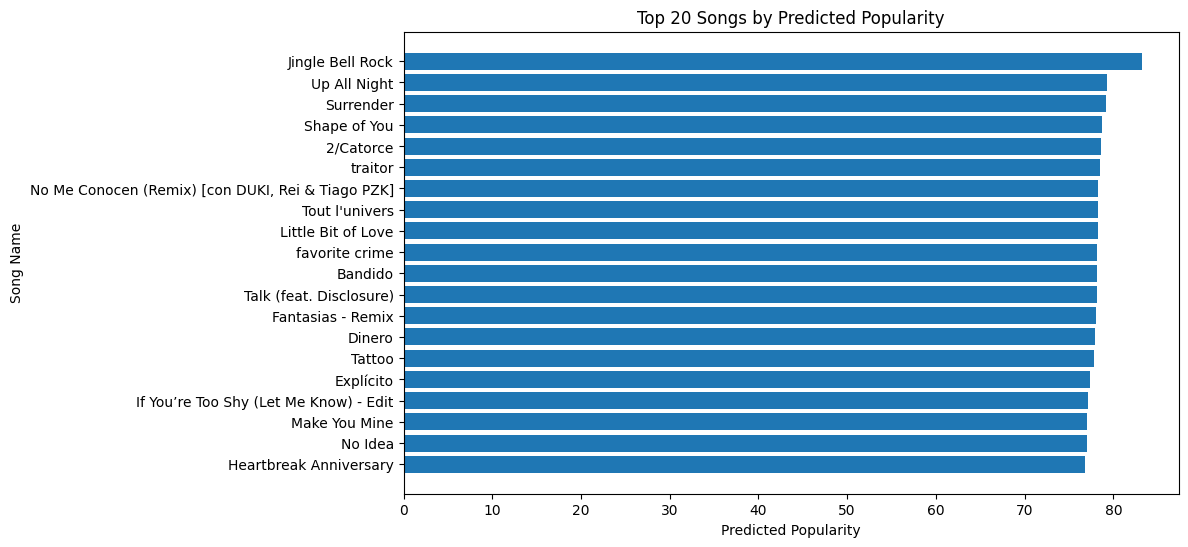

In [ ]:
top_20 = prediction_results.sort_values(
    by="Predicted Popularity",
    ascending=False
).head(20)

plt.figure(figsize=(10, 6))
plt.barh(top_20["Song Name"], top_20["Predicted Popularity"])
plt.gca().invert_yaxis()
plt.xlabel("Predicted Popularity")
plt.ylabel("Song Name")
plt.title("Top 20 Songs by Predicted Popularity")
plt.show()

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_squared_error
import numpy as np
import pandas as pd
import xgboost as xgb

X_train, X_test, y_train, y_test, song_train, song_test, artist_train, artist_test = train_test_split(
    X,
    y,
    song_names,
    artists,
    test_size=0.2,
    random_state=42
)

models = {
    "Decision Tree": DecisionTreeRegressor(max_depth=3, random_state=42),
    "Random Forest": RandomForestRegressor(n_estimators=100, max_depth=3, random_state=42),
    "Gradient Boosting": GradientBoostingRegressor(n_estimators=100, learning_rate=0.05, max_depth=3, random_state=42),
    "XBooster": xgb.XGBRegressor(objective ='reg:squarederror', verbosity=0, seed = 10)
}

results = []
predictions = {}

for model_name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    rmse = np.sqrt(mean_squared_error(y_test, y_pred))

    results.append({
        "Model": model_name,
        "RMSE": rmse
    })

    predictions[model_name] = y_pred

rmse_results = pd.DataFrame(results).sort_values("RMSE")
rmse_results

,Model,RMSE
3,XBooster,9.314497
2,Gradient Boosting,9.458508
1,Random Forest,9.678346
0,Decision Tree,9.945495


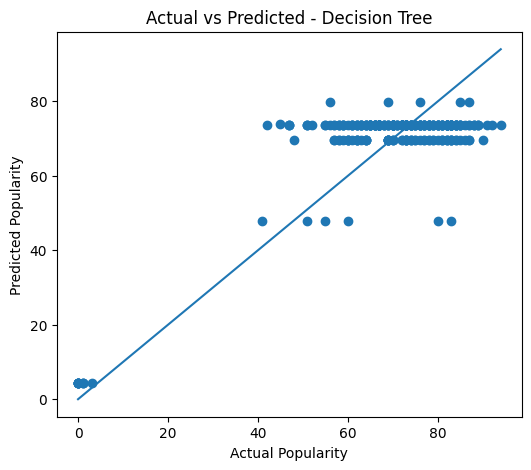

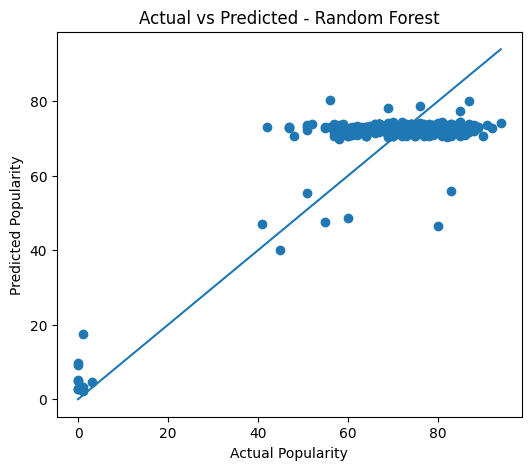

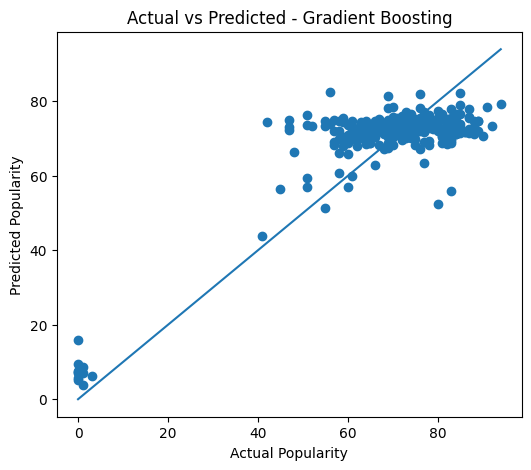

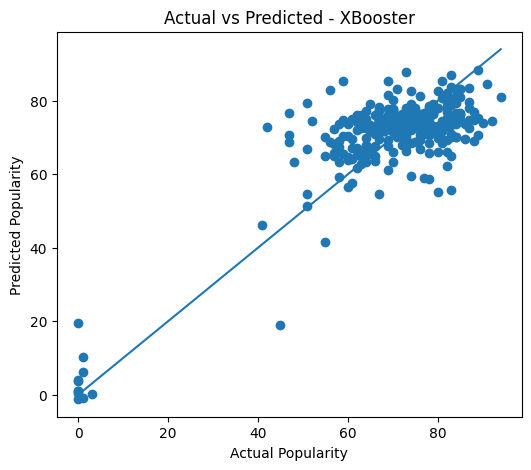

In [ ]:
for model_name, model in models.items():
    y_pred = model.predict(X_test)

    plt.figure(figsize=(6, 5))
    plt.scatter(y_test, y_pred)
    plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()])
    plt.xlabel("Actual Popularity")
    plt.ylabel("Predicted Popularity")
    plt.title(f"Actual vs Predicted - {model_name}")
    plt.show()

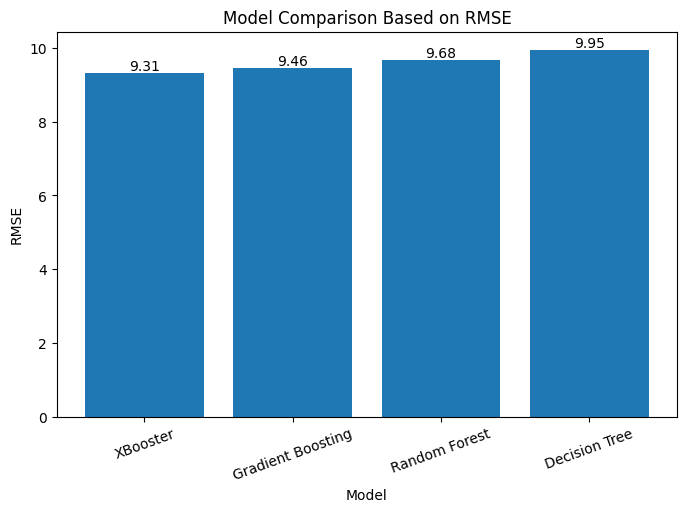

In [ ]:
plt.figure(figsize=(8, 5))
bars = plt.bar(rmse_results["Model"], rmse_results["RMSE"])

for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        height,
        round(height, 2),
        ha="center",
        va="bottom"
    )

plt.xlabel("Model")
plt.ylabel("RMSE")
plt.title("Model Comparison Based on RMSE")
plt.xticks(rotation=20)
plt.show()

In [ ]:
from sklearn.model_selection import cross_val_score

cv_results = []

for model_name, model in models.items():
    scores = cross_val_score(
        model,
        X,
        y,
        scoring="neg_root_mean_squared_error",
        cv=5
    )

    rmse_scores = -scores

    cv_results.append({
        "Model": model_name,
        "Mean CV RMSE": rmse_scores.mean(),
        "Std CV RMSE": rmse_scores.std()
    })

cv_results_df = pd.DataFrame(cv_results).sort_values("Mean CV RMSE")
cv_results_df

,Model,Mean CV RMSE,Std CV RMSE
2,Gradient Boosting,11.630158,2.910497
1,Random Forest,11.785258,2.781108
3,XBooster,12.283350,2.970643
0,Decision Tree,12.362647,3.207601


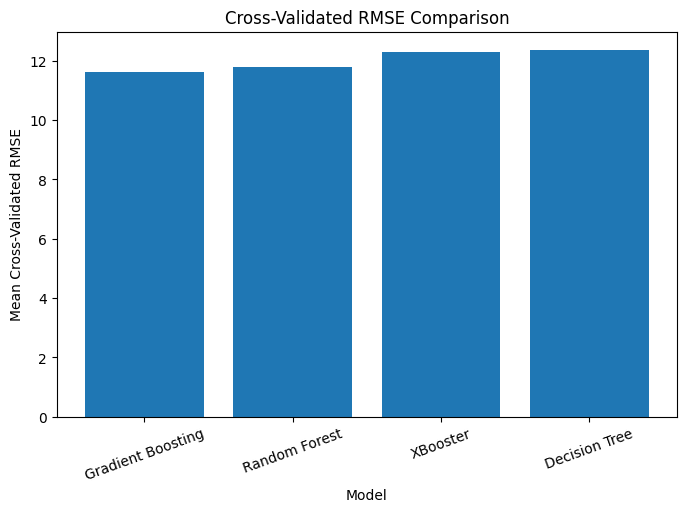

In [ ]:
plt.figure(figsize=(8, 5))
plt.bar(cv_results_df["Model"], cv_results_df["Mean CV RMSE"])
plt.xlabel("Model")
plt.ylabel("Mean Cross-Validated RMSE")
plt.title("Cross-Validated RMSE Comparison")
plt.xticks(rotation=20)
plt.show()

In [ ]:
best_model = models["XBooster"]
best_model.fit(X_train, y_train)

feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": best_model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

feature_importance.head(10)

,Feature,Importance
1,Genre,0.405060
0,Artist Followers,0.194243
5,Speechiness,0.053998
4,Loudness,0.047101
10,Valence,0.045898
6,Acousticness,0.042153
8,Tempo,0.040666
7,Liveness,0.038865
9,Duration (ms),0.037359
3,Energy,0.034046
